# Exercise 02 — Neural Network Basics

In this session you build the core components of a neural network **from scratch** in PyTorch, and then use PyTorch's own building blocks to train a real image classifier.

## What you will do
1. **Activation functions** — implement ReLU and Sigmoid, and their derivatives.
2. **The Perceptron** — a single neuron: weighted sum + bias + activation.
3. **The Linear layer** — many perceptrons stacked into one matrix multiplication.
4. **The MLP** — linear layers with nonlinearities in between.
5. **MSE loss** — implement the loss and its gradient.
6. **The whole pipeline** — train and evaluate a classifier on FashionMNIST.
7. **Multiple-choice questions** — check your understanding.

## How to work through this notebook
- Every place that needs your input is marked with a `# TODO` comment and/or `...`. **Replace every `...` with your own code.**
- Questions marked *Your answer here* are written answers — double-click the markdown cell and type directly into it.
- After most implementations there is a **verification cell** that compares your code against PyTorch's built-in modules. You are done with a part when the printed difference is (near) zero.
- Run the cells **in order** — later cells depend on variables defined earlier.

Please update your environment before running this notebook using <code onclick="navigator.clipboard.writeText(this.textContent)" style="cursor:pointer" title="Click to copy">uv sync</code>.

In [107]:
from os import abort

from sympy.tensor import tensor
%matplotlib inline
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor

## 1. Activation functions

### ReLU

Activation functions are crucial components of neural networks because they introduce non-linear behavior. Without them, a network composed of stacked linear transformations would still behave like a single linear model, limiting its ability to capture complex patterns in the data.

One of the most widely used activation functions today is the Rectified Linear Unit (ReLU), defined as

\begin{align}
ReLU(x) = \begin{cases}
               0               & x<0\\
               x               & x\geq 0\\ \end{cases}
\end{align}


**1.1 Find the derivative of the ReLU function, $R'(x)$. Carefully consider the two regions when $x<0$ and $x\geq0$.** <br>

---

*Your answer here:*
\begin{align}
\frac{\partial}{\partial x} ReLU(x) = \begin{cases}
               0               & x<0\\
               1               & x> 0\\ \end{cases}
\end{align}

---
**1.2 Fill in the missing parts of the class below so that it computes both the ReLU activation and its derivative.**

Hints:
- Both methods take a tensor `x` and must return a tensor **of the same shape**.
- A boolean mask such as `(x > 0)` can be multiplied with a tensor — that is enough to write both methods in one line each, no loops or `if` statements needed.


In [108]:
class ReLU:
    @staticmethod
    def forward(x: torch.Tensor):
        # TODO: return ReLU(x) — x where x >= 0, and 0 elsewhere
        return x.clamp_min(0)

    @staticmethod
    def gradient(x: torch.Tensor):
        # TODO: return R'(x), the derivative you found in 1.1
        return (x > 0).to(x.dtype)

### Sigmoid

One of the classical choices is the sigmoid function, which smoothly squashes any real-valued input into the range (0,1). This property made it popular in the early days of neural networks, particularly for binary classification problems, since its output can be interpreted as a probability.

\begin{align}
S(z) = \frac{1}{1 + e^{-z}}.
\end{align}

**1.3 Find the derivative of the Sigmoid function, $S'(x)$.** <br>

---

*Your answer here:*
\begin{align}
\frac{\partial}{\partial x} \sigma(x) &= \frac{\partial}{\partial x} \frac{1}{1+e^{-x}} \\
                                        &= \frac{\partial}{\partial x}(1+e^{-x})^{-1} \\
                                        &= -(1+e^{-x})^{-2}\frac{\partial}{\partial x}(1 + e^{-x}) \\
                                        &= -(1+e^{-x})^{-2}(-e^{-x}) \\
                                        &= \frac{e^{-x}}{(1+e^{-x})^2}
\end{align}
---
**1.4 Fill in the missing parts of the class below so that it computes both the Sigmoid activation and its derivative.**

Hints:
- Use `torch.exp` for the exponential.
- The derivative can be written compactly in terms of $S(x)$ itself — you can call `Sigmoid.forward(x)` from inside `gradient`.


In [109]:
class Sigmoid:
    @staticmethod
    def forward(x: torch.Tensor):
        # TODO: return S(x) = 1 / (1 + exp(-x))
        return 1 / (1 + torch.exp(-x))

    @staticmethod
    def gradient(x: torch.Tensor):
        # TODO: return S'(x), the derivative you found in 1.3
        return torch.exp(-x) / (1 + torch.exp(-x))**2

**1.5 Check your two implementations against PyTorch's built-in `torch.relu` and `torch.sigmoid`.**


In [110]:
x = torch.linspace(-5, 5, 11)

print("ReLU    matches torch:", torch.allclose(ReLU.forward(x), torch.relu(x)))
print("Sigmoid matches torch:", torch.allclose(Sigmoid.forward(x), torch.sigmoid(x)))

ReLU    matches torch: True
Sigmoid matches torch: True


**1.6 Plot both activations together with their derivatives over the range defined below.**

- Use the **2 × 2 grid of subplots** that is already created for you: ReLU and its derivative on the top row, Sigmoid and its derivative on the bottom row.
- Label your axes, give each subplot a **title**, and don't forget the **legends**.
- Look at the plots: where is each derivative (close to) zero? That is where a neuron stops learning — we will come back to this when we discuss vanishing gradients.


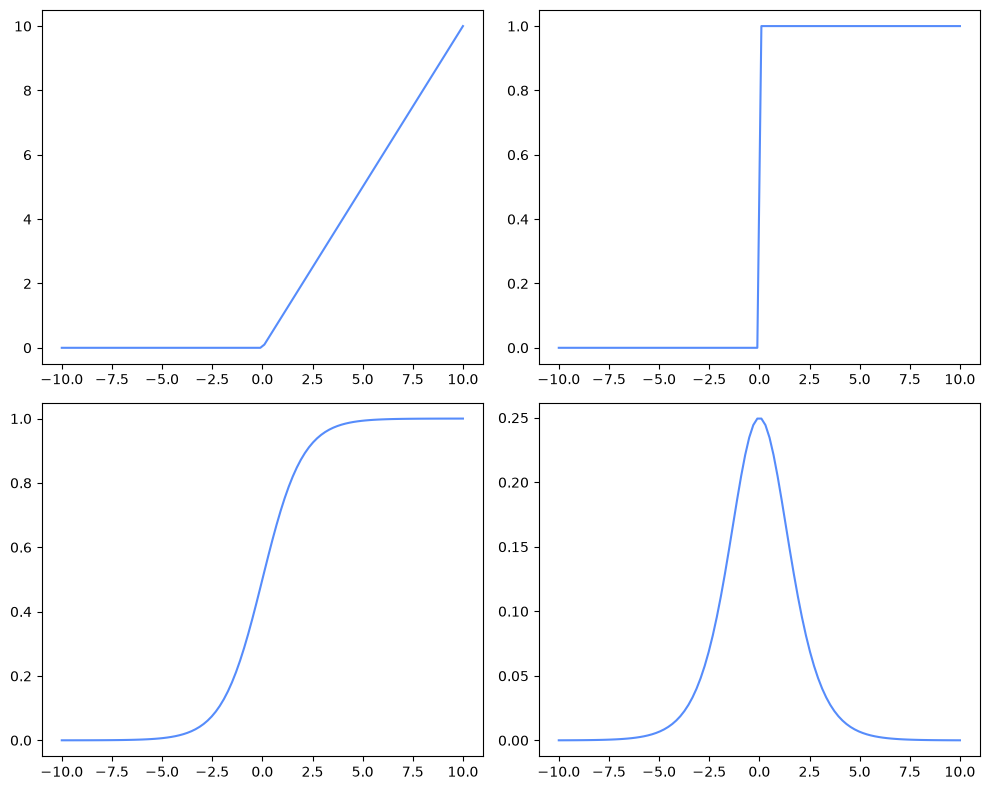

In [111]:
x = torch.linspace(-10, 10, 100)

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# TODO: compute the four curves: ReLU(x), ReLU'(x), Sigmoid(x), Sigmoid'(x)
relu_x = ReLU.forward(x)
relu_d = ReLU.gradient(x)
sigmoid_x = Sigmoid.forward(x)
sigmoid_d = Sigmoid.gradient(x)

# TODO: plot them on axs[0, 0], axs[0, 1], axs[1, 0] and axs[1, 1],
#       and add a title, axis labels and a legend to each subplot
axs[0, 0].plot(x, relu_x)
axs[0, 1].plot(x, relu_d)
axs[1, 0].plot(x, sigmoid_x)
axs[1, 1].plot(x, sigmoid_d)

plt.tight_layout()
plt.show()

## 2. The Perceptron

The **perceptron** is the simplest model of a neuron.  
Given an input vector $(x \in \mathbb{R}^d)$, it computes:

\begin{align}
y = \phi\!\left(\sum_{i=1}^{d} w_i x_i + b\right),
\end{align}

where  
- $(x_i)$ are the inputs,  
- $(w_i)$ are the corresponding weights,  
- $(b)$ is the bias term,  
- $(\phi(\cdot))$ is the activation function (e.g., sigmoid, ReLU, etc.).  

**2.1 Implement a `Perceptron` class with:**
   - a constructor that initialises the weights and the bias randomly,  
   - a `forward(x)` method that returns the activated output.

Hints:
- Wrap the weights and the bias in `torch.nn.Parameter(...)` so that PyTorch registers them as learnable parameters of the module.
- For an input of dimension `d`, `W` has shape `(d,)` and `b` is a scalar — `torch.randn(d)` and `torch.randn(())`.
- Use the `Sigmoid` class you wrote in Part 1 as the activation $\phi$.


In [112]:
class Perceptron(torch.nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        # TODO: initialise the weights and the bias randomly
        #       (wrap them in torch.nn.Parameter so they are learnable)
        self.W = torch.nn.Parameter(torch.randn((1, input_dim)))
        self.b = torch.nn.Parameter(torch.randn(1))

    def forward(self, x):
        # TODO: compute z = W·x + b
        z = self.W @ x + self.b
        # TODO: apply the sigmoid activation and return the result
        return Sigmoid.forward(z)

**2.2 To verify your implementation recreate the Perceptron using Pytorch's built-in `torch.nn` modules and check that they behave in the same way**

PyTorch already provides layers for you:

- Look at `torch.nn.Linear` for the weight + bias computation.
- Don’t forget to apply an activation function afterwards — check out modules in `torch.nn`.
- You can combine them in sequence using `nn.Sequential`.

In [113]:
# Create both layers
in_features, out_features = 3, 1
my_layer = Perceptron(in_features)              # TODO: your own Perceptron
TorchPerceptron = nn.Sequential(
    nn.Linear(in_features, out_features),                    # TODO: the linear part (weights + bias)
    nn.Sigmoid(),                    # TODO: the activation
)

print("my W:", my_layer.W.shape)
print("torch W:", TorchPerceptron[0].weight.shape)

print("my b:", my_layer.b.shape)
print("torch b:", TorchPerceptron[0].bias.shape)

# Copy parameters from your layer into the torch version, so both compute the same function
with torch.no_grad():
    TorchPerceptron[0].weight.copy_(my_layer.W)
    TorchPerceptron[0].bias.copy_(my_layer.b)

# Test input
x = torch.rand(in_features)
y_my = my_layer(x)
y_torch = TorchPerceptron(x)

print("My implementation:", y_my)
print("torch.nn:         ", y_torch)
print("Difference:       ", torch.abs(y_my - y_torch).max().item())

my W: torch.Size([1, 3])
torch W: torch.Size([1, 3])
my b: torch.Size([1])
torch b: torch.Size([1])
My implementation: tensor([0.3705], grad_fn=<MulBackward0>)
torch.nn:          tensor([0.3705], grad_fn=<SigmoidBackward0>)
Difference:        0.0


## 3. The Linear Layer

A perceptron takes one input vector and produces a single output after applying a weighted sum, a bias, and an activation.  

A **linear layer** is simply a collection of multiple perceptrons stacked together.  
- Instead of one weight vector $(w)$, we now have a weight matrix $(W \in \mathbb{R}^{m \times d})$.  
- Each row of $(W)$ corresponds to the weights of one perceptron.  
- The bias term becomes a vector $(b \in \mathbb{R}^m)$.  
- The output is a vector $(y \in \mathbb{R}^m)$:  

\begin{align}
y &= W x + b
\end{align}

where  
- $x$ is the input of dimension $d$,  
- $W$ applies $m$ linear combinations of the inputs,  
- $b$ shifts (translates) the result.

This is often called an **affine transformation**: a linear transformation plus a translation.

**3.1 Fill in the code below to implement your own linear layer.**

Hints:
- `W` has shape `(out_features, in_features)` and `b` has shape `(out_features,)`. This is the same convention as `torch.nn.Linear`, which is what makes the verification in 3.2 work.
- Wrap both in `torch.nn.Parameter(...)` again.
- Note that there is **no activation function** here: a linear layer is purely affine. The nonlinearity is applied separately, as you will see in Part 4.


In [114]:
class Linear(torch.nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        # TODO: initialise the weight matrix W of shape (out_features, in_features)
        #       and the bias vector b of shape (out_features,)
        self.W = torch.nn.Parameter(torch.randn(out_features, in_features))
        self.b = torch.nn.Parameter(torch.randn(out_features))

    def forward(self, x: torch.Tensor):
        # TODO: implement y = W x + b
        return self.W @ x + self.b

**3.2 To verify your implementation recreate the Linear Layer using Pytorch's built-in `torch.nn` modules and check that they behave in the same way**

In [115]:
# Create both layers
in_features, out_features = 3, 2
my_layer = Linear(in_features, out_features)            # TODO: your own Linear layer
TorchLinearLayer = torch.nn.Linear(in_features, out_features)    # TODO: the equivalent torch.nn module

# Copy parameters from your layer to torch.nn.Linear
with torch.no_grad():
    TorchLinearLayer.weight.copy_(my_layer.W)
    TorchLinearLayer.bias.copy_(my_layer.b)

# Test input
x = torch.rand(in_features)

# TODO: compute the output of both implementations
y_my = my_layer.forward(x)
y_torch = TorchLinearLayer.forward(x)

print("My implementation:", y_my)
print("torch.nn.Linear:  ", y_torch)
print("Difference:       ", torch.abs(y_my - y_torch).max().item())

My implementation: tensor([ 0.9141, -0.1634], grad_fn=<AddBackward0>)
torch.nn.Linear:   tensor([ 0.9141, -0.1634], grad_fn=<ViewBackward0>)
Difference:        0.0


## 4. Multi-Layer Perceptron (MLP)
So far, you built:
- a Perceptron → single linear unit + nonlinearity
- a Linear layer → general affine transformation (x @ W^T + b)

These are the *building blocks* of neural networks.

A **Multi-Layer Perceptron (MLP)** is simply a stack of perceptrons (linear layers with nonlinearities between them).

- The first layer transforms the input into a hidden representation.
- A nonlinear activation (e.g., ReLU, Sigmoid, Tanh) makes the model expressive.
- The next layer(s) take the hidden representation and produce outputs.

\begin{align}
\mathbf{a}_{l} &= {\mathbf{W}}_{l}^T \mathbf{x}_{l-1} + \mathbf{b}_{l}\;. \\
\end{align}

Followed by the nonlinear activation 
\begin{align}
\mathbf{x}_{l} &= f_{l}(\mathbf{a}_{l})
\end{align}

where:
- $f_l$; Activation function for layer $l$
- $x_l$: The output of layer $l$.
- ${\mathbf{W}}_{l}$ Weights of layer $l$.
- $\mathbf{b}_{l}$ Bias of layer $l$.

**4.1 Fill in the code below to implement your own MLP class.**

The architecture is: `Linear(D_in → H)` → `ReLU` → `Linear(H → D_out)`.

Hints:
- You need **two** weight matrices and **two** bias vectors: `W1, b1, W2, b2`.
- Keep the `torch.nn.Linear` convention: `W1` has shape `(H, D_in)`, `W2` has shape `(D_out, H)`.
- Write `forward` so that it works both for a single sample of shape `(D_in,)` **and** for a batch of shape `(N, D_in)`. Writing the layer as `x @ W.T + b` handles both cases at once.
- Use `F.relu` (or the `ReLU` class from Part 1) for the nonlinearity.
- The final layer output is left **unactivated** (raw scores).


In [116]:
class MyMLP(torch.nn.Module):
    def __init__(self, D_in, H, D_out):
        """
        D_in: input dimension
        H: hidden dimension
        D_out: output dimension
        """
        super().__init__()
        # TODO: initialise the first layer  (W1: (H, D_in),   b1: (H,))
        self.W1 = torch.nn.Parameter(torch.randn(H, D_in))
        self.b1 = torch.nn.Parameter(torch.randn(H))
        # TODO: initialise the second layer (W2: (D_out, H),  b2: (D_out,))
        self.W2 = torch.nn.Parameter(torch.randn(D_out, H))
        self.b2 = torch.nn.Parameter(torch.randn(D_out))

    def forward(self, x):
        # x can have shape (D_in,) or (N, D_in)
        # TODO: first linear layer -> ReLU -> second linear layer

        r_in = x @ self.W1.T + self.b1
        r_out = ReLU.forward(r_in)

        return r_out @ self.W2.T + self.b2

**4.2 To verify your implementation recreate the MLP using Pytorch's built-in `torch.nn` modules and check that they behave in the same way**

In [117]:
torch.manual_seed(0)
D_in, H, D_out = 3, 4, 1

manual = MyMLP(D_in, H, D_out)

# TODO: build the equivalent network with nn.Sequential (Linear -> ReLU -> Linear)
TorchMLP = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
)

# TODO: copy W1, b1, W2, b2 from `manual` into TorchMLP, so both compute exactly
#       the same function. Hint: TorchMLP[0] is the first Linear, TorchMLP[2] the second.
with torch.no_grad():
    TorchMLP[0].weight.copy_(manual.W1)
    TorchMLP[0].bias.copy_(manual.b1)
    TorchMLP[2].weight.copy_(manual.W2)
    TorchMLP[2].bias.copy_(manual.b2)

# --- Single example ---
x1 = torch.tensor([0.5, -1.0, 2.0])
y_manual_1 = manual(x1)
y_torch_1 = TorchMLP(x1)
print("single:", torch.allclose(y_manual_1, y_torch_1, atol=1e-7), y_manual_1, y_torch_1)

# --- Batch of examples ---
xB = torch.randn(5, D_in)

# TODO: compute the output of both implementations on the batch
y_manual_B = manual(xB)
y_torch_B = TorchMLP(xB)

print("batch: ", torch.allclose(y_manual_B, y_torch_B, atol=1e-7))

single: True tensor([-0.9602], grad_fn=<AddBackward0>) tensor([-0.9602], grad_fn=<ViewBackward0>)
batch:  True


## 5. Mean Squared Error (MSE) Loss

The Mean Squared Error (MSE) measures how far predictions are from the true values by averaging the squared differences.

For $N$ predictions $\hat{y}_i$ and true labels $y_i$:

\begin{align}
\mathcal{L}_{\text{MSE}} &= \frac{1}{N} \sum_{i=1}^N (\hat{y}_i - y_i)^2
\end{align}

**5.1 Find the derivative of the MSE loss with respect to a single prediction $\hat{y}_i$.** <br>

---

*Your answer here:*
\begin{align}
\frac{\partial}{\partial \hat y_i} \frac{1}{N} \sum_{i=1}^N (\hat{y}_i - y_i)^2 &= \frac{1}{N} 2(\hat{y}_i - y_i) \frac{\partial}{\partial \hat y_i} (\hat{y}_i - y_i) \\
                                                     &= \frac{1}{N} 2(\hat{y}_i - y_i) 1 \\
                                                     &= \frac{2}{N} (\hat{y}_i - y_i)
\end{align}

NOTE: The sum dissapears since all except $y_i$ becomes $0$ when taking the derivative.

---
**5.2 Fill in the missing parts of the class below so that it computes both the loss and its gradient with respect to the predictions.**

Hints:
- `loss` returns a **scalar**; `gradient` returns a tensor **of the same shape as `y_pred`** (one partial derivative per prediction).
- Careful with the normalisation: in the test below `y_pred` has shape `(N, C)`, and — like `torch.nn.MSELoss()` with its default `reduction="mean"` — the average is taken over **all** $N \cdot C$ elements, not just over $N$. So the constant in front is $2 / (N \cdot C)$.


In [118]:
class MSE:
    @staticmethod
    def loss(y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
        # TODO: return the mean squared error as a single scalar
        return ((y_pred - y_true)**2).mean() # Maybe use mean instead.

    @staticmethod
    def gradient(y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
        # TODO: return dL/dy_pred — a tensor with the same shape as y_pred
        return 2 * (y_pred - y_true) / (y_true.shape[0] * y_true.shape[1])

**5.3 Compare against PyTorch’s built-in implementation. You can use `torch.nn.MSELoss` to compute the loss and gradients automatically.**

In [119]:
N, C = 5, 3
y_true = torch.rand(N, C)                      
y_pred = torch.rand(N, C, requires_grad=True)  

# --- Built-in PyTorch loss ---
loss_fn = torch.nn.MSELoss()        # TODO: instantiate torch.nn.MSELoss
torch_loss = loss_fn(y_pred, y_true)     # TODO: compute the loss on (y_pred, y_true)

# Backprop to get gradients
torch_loss.backward()
torch_grad = y_pred.grad.clone()

# --- Your implementation ---
manual_loss = MSE.loss(y_true, y_pred)    # TODO: use your MSE.loss
manual_grad = MSE.gradient(y_true, y_pred)    # TODO: use your MSE.gradient

# --- Compare ---
print("PyTorch loss:", torch_loss.item())
print("Manual loss:", manual_loss.item())

print("\nPyTorch gradient:\n", torch_grad)
print("Manual gradient:\n", manual_grad)

print("\nLoss close?  ", torch.allclose(torch_loss, manual_loss))
print("Grad close?  ", torch.allclose(torch_grad, manual_grad))

PyTorch loss: 0.22341936826705933
Manual loss: 0.22341936826705933

PyTorch gradient:
 tensor([[-0.0286,  0.0760,  0.0159],
        [ 0.0063, -0.0545,  0.1125],
        [ 0.0841, -0.1189, -0.0615],
        [ 0.0321,  0.0265,  0.0793],
        [ 0.0274,  0.0542,  0.0189]])
Manual gradient:
 tensor([[-0.0286,  0.0760,  0.0159],
        [ 0.0063, -0.0545,  0.1125],
        [ 0.0841, -0.1189, -0.0615],
        [ 0.0321,  0.0265,  0.0793],
        [ 0.0274,  0.0542,  0.0189]], grad_fn=<DivBackward0>)

Loss close?   True
Grad close?   True


## 6. The whole Pipeline: Training on FashionMNIST

You have now written every ingredient of a neural network by hand. From here on we use PyTorch's own modules and put the whole pipeline together: load a dataset, define a model, choose a loss and an optimiser, train, evaluate, and save the result.


### Loading the FashionMNIST Dataset

We will use **FashionMNIST**, a dataset of grayscale 28×28 images of clothing items (e.g., shirts, shoes, bags).  
It is built into PyTorch and can be easily downloaded.

#### Datasets and Dataloaders
- A **Dataset** object (like `datasets.FashionMNIST`) gives you access to the data samples and their labels.  
- A **DataLoader** wraps a dataset and helps you:
  - Load the data in **mini-batches** (instead of one sample at a time).  
  - **Shuffle** the data during training (good for generalization).  
  - Use multiple worker processes to speed up loading.  

In practice, you almost always combine a Dataset with a DataLoader when training models in PyTorch.


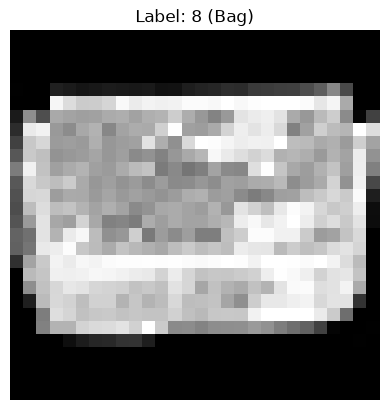

In [120]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

# Wrap the datasets in DataLoaders: mini-batches, and shuffling for the training set.
batch_size = 64
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

# Look at one random training example
sample_idx = torch.randint(len(training_data), size=(1,)).item()
img, label = training_data[sample_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Label: {label} ({training_data.classes[label]})")
plt.axis("off")
plt.show()

**6.1 How many features does each sample have?**

**6.2 How many classes does the dataset have?**

*Hint: `img.shape` and `training_data.classes` will tell you. You will need both numbers to build the model below.*

---

*Your answers here:*  

---


### Choosing a Device (CPU or GPU)

Training deep learning models can be much faster on a GPU, if one is available.  
In PyTorch, we usually set a `device` variable so that both the model and the data can be placed consistently on either:

- **GPU (`"cuda"`)** → preferred for faster training when available  
- **CPU (`"cpu"`)** → always available, sufficient for small exercises  

For this exercise, using a GPU is **not required** — but it’s good practice to write code that supports both.


In [121]:
# Select GPU if available, otherwise fall back to CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using {device} device")

Using cpu device


### Defining a Neural Network in PyTorch

We now define a simple **feedforward neural network** for image classification.

- **`nn.Flatten()`** → converts a 2D image (28×28 pixels) into a 1D tensor (length 784).  
- **`nn.Sequential()`** → a container that runs layers in order. Here it includes:  
  1. A linear (fully connected) layer mapping from `28*28` inputs to a hidden dimension.  
  2. A **ReLU** activation function for nonlinearity.  
  3. Another linear layer mapping from the hidden dimension to 10 output classes.

The network returns **logits** (unnormalized scores for each class).


In [122]:
class NeuralNetwork(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(in_features, hidden_features),
            nn.ReLU(),
            nn.Linear(hidden_features, out_features),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits


# TODO: initialise the model with the arguments that match our dataset
#       (in_features = number of pixels per image, out_features = number of classes,
#        i.e. the two numbers you found in 6.1 and 6.2), and move it to the device
#       with .to(device).
# Hint: use 512 hidden features.

model = NeuralNetwork(img.shape[1] * img.shape[2], 512, len(training_data.classes))

# Display the model architecture
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=10, bias=True)
  )
)


### Hyperparameters, Loss Function, and Optimizer

To train our neural network, we need to set a few key choices:

- **Learning rate**: controls how big each parameter update step is.  
- **Batch size**: number of samples processed together before updating weights.  
- **Epochs**: how many full passes we make over the training dataset.  

We also need:

- **Loss function**: measures how far the model’s predictions are from the true labels.  
  - Here we use **Cross-Entropy Loss**, the standard choice for multi-class classification.  
- **Optimizer**: updates model parameters using the gradients.  
  - Here we use **Stochastic Gradient Descent (SGD)** with the chosen learning rate.


In [123]:
# Hyperparameters
learning_rate = 1e-3
epochs = 10
# (batch_size was already set above, when we created the DataLoaders)

# Loss function (for classification)
loss_fn = nn.CrossEntropyLoss()

# Optimizer (SGD with given learning rate)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

### Training and Evaluating a Neural Network

Once we have a dataset and a model, the next step is to **train** the model so that it can make accurate predictions.

### Training
Training is the process of teaching the model to minimize a **loss function** by adjusting its parameters (weights and biases).  
This is done using an algorithm called **backpropagation** combined with an **optimizer** (such as SGD or Adam).
We will be looking closer at backpropagation in the next sessions.

The training loop typically consists of:
1. **Forward pass** → feed the input through the model to get predictions.  
2. **Compute the loss** → measure how far predictions are from the true labels.  
3. **Backward pass** → compute gradients of the loss with respect to model parameters.  
4. **Update parameters** → use the optimizer to adjust weights and biases.  

Repeating this process over the dataset (for multiple **epochs**) gradually improves the model.

### Evaluation
After training, we need to evaluate the model on **unseen data** (the test set).  
During evaluation:
- We disable gradient calculations (`torch.no_grad()`), since we are not training.  
- The model is set to **evaluation mode** (`model.eval()`), which is important for certain layers (e.g., dropout, batch normalization).  
- We measure **accuracy** and **average loss** to understand how well the model generalizes.


**6.3 Complete the `train` function below, then run it for 10 epochs in the following cell.**

Note: training for 10 epochs on CPU takes a few minutes — this is a good moment to go back over Parts 1–5.


In [124]:
def train(dataloader, model: NeuralNetwork, loss_fn, optimizer, losses=None):
    if losses is None:
        losses = []
    model.train()  # set model to training mode

    for batch, (X, y) in enumerate(dataloader):
        # Move the batch to the same device as the model
        X, y = X.to(device), y.to(device)

        # Forward pass
        # TODO: perform the forward pass
        pred = model.forward(X)

        # Compute the loss
        loss = loss_fn(pred, y)

        # Just for logging
        losses.append(loss.item())

        # Backpropagation
        optimizer.zero_grad() # 1. Reset gradients
        loss.backward()       # 2. Compute current gradients
        optimizer.step()      # 3. Update parameters

        if batch % 100 == 0:
            print(f"  batch {batch:>4d}  loss: {loss.item():>7f}")
    return losses

Now run the training loop. Each call to `train` performs one full pass (epoch) over the training set.


In [125]:
losses = []
for t in range(epochs):
    print(f"Epoch {t + 1}\n" + "-" * 15)
    # TODO: call `train` for this epoch, appending to `losses`
    train(train_dataloader, model, loss_fn, optimizer, losses)

print("Done!")

Epoch 1
---------------
  batch    0  loss: 2.314061
  batch  100  loss: 2.226285
  batch  200  loss: 2.157422
  batch  300  loss: 2.115355
  batch  400  loss: 2.024425
  batch  500  loss: 1.958164
  batch  600  loss: 2.012776
  batch  700  loss: 1.953242
  batch  800  loss: 1.829149
  batch  900  loss: 1.819863
Epoch 2
---------------
  batch    0  loss: 1.775412
  batch  100  loss: 1.707294
  batch  200  loss: 1.653108
  batch  300  loss: 1.552139
  batch  400  loss: 1.655816
  batch  500  loss: 1.523846
  batch  600  loss: 1.556074
  batch  700  loss: 1.412414
  batch  800  loss: 1.354728
  batch  900  loss: 1.377680
Epoch 3
---------------
  batch    0  loss: 1.371691
  batch  100  loss: 1.363378
  batch  200  loss: 1.475885
  batch  300  loss: 1.229914
  batch  400  loss: 1.276276
  batch  500  loss: 1.317019
  batch  600  loss: 1.276749
  batch  700  loss: 1.202396
  batch  800  loss: 1.170286
  batch  900  loss: 1.150150
Epoch 4
---------------
  batch    0  loss: 1.212318
  bat

**6.4 Complete the `test` function so that it evaluates the model on the test dataset.**

It should return the **accuracy in %** and the **average loss per batch**. Remember to:
- put the model in evaluation mode,
- run the loop inside `torch.no_grad()`,
- move each batch to `device`,
- count a prediction as correct when the class with the highest logit matches the label — `pred.argmax(1) == y`,
- divide the accumulated loss by the number of *batches*, and the number of correct predictions by the number of *samples* (`len(dataloader)` vs `len(dataloader.dataset)`).


In [126]:
def test(dataloader, model: NeuralNetwork, loss_fn):
    """
    Evaluate the model on the test dataset.
    Returns: (accuracy in %, average loss per batch)
    """
    # TODO: set the model to evaluation mode
    model.eval()
    test_loss, correct = 0, 0

    # TODO: loop over the dataloader without tracking gradients, moving each batch
    #       to `device`, and accumulate the loss and the number of correct predictions
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        test_loss += loss.item()
        correct += (pred.argmax(dim=1) == y).sum().item()

    # TODO: normalise both numbers and return (accuracy in %, average loss)
    accuracy = correct / len(dataloader.dataset)
    avg_loss = test_loss / len(dataloader.dataset)
    return (accuracy * 100, avg_loss)


accuracy, avg_loss = test(test_dataloader, model, loss_fn)
print(f"Test accuracy: {accuracy:>0.1f}%, average loss: {avg_loss:>8f}")

Test accuracy: 74.1%, average loss: 0.011634


**6.5 Plot the training loss you recorded.**

The `losses` list holds one value per mini-batch. Plot it (x-axis: training step, y-axis: loss) and look at the shape of the curve: is the loss still going down at the end, or has it flattened out? What would you change if it were still falling steeply?


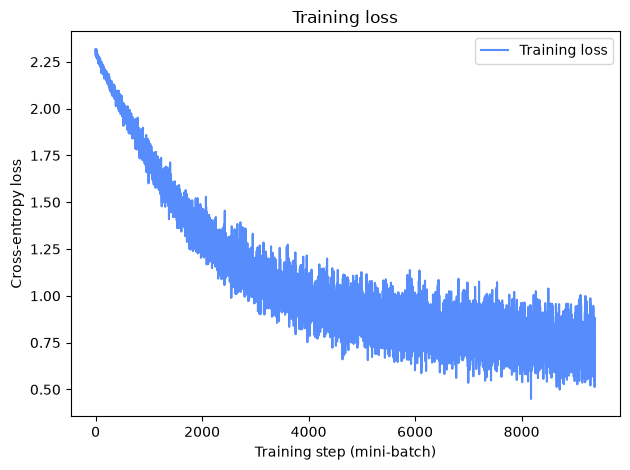

In [131]:
# TODO: plot the recorded training losses
#       (x-axis: training step / mini-batch, y-axis: loss)

fig, ax = plt.subplots()
ax.plot(losses, label="Training loss")
ax.set_xlabel("Training step (mini-batch)")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Training loss")
ax.legend()

plt.tight_layout()
plt.show()


### Saving and Loading Models in PyTorch

After training a neural network, it’s important to save the learned parameters so we can reuse the model later without retraining from scratch.

In PyTorch, we typically save the **state dictionary** (`state_dict`) of the model, which contains all trainable parameters (weights and biases).  

```python
torch.save(model.state_dict(), "model_weights.pth")
```

To reuse a saved model:

1. Recreate the model architecture.
2. Load the saved state dictionary into it.
3. Evaluate or continue training as needed.

This way, the new model has the same parameters as the trained one.

**6.6 Save your trained model, load the weights back into a fresh instance, and verify that it reaches the same test accuracy.**


In [132]:
# Save the trained model's parameters
torch.save(model.state_dict(), "model_weights.pth")

# TODO: create a new (untrained) instance of the model with the same architecture
model_new = NeuralNetwork(img.shape[1] * img.shape[2], 512, len(training_data.classes))

# Load the saved parameters into it
model_new.load_state_dict(torch.load("model_weights.pth"))
model_new.to(device)

accuracy, avg_loss = test(test_dataloader, model_new, loss_fn)
print(f"Reloaded model — test accuracy: {accuracy:>0.1f}%, average loss: {avg_loss:>8f}")

Reloaded model — test accuracy: 74.1%, average loss: 0.011634


## 7. MCQ

Answer each question by writing the letter of your choice (A–D) after **Answer:**.

---

### 7.1 Activation Functions
Which of the following is the main purpose of using an activation function in a neural network?  

A. To increase the number of layers in the network  
B. To introduce non-linearity so the network can model complex functions  
C. To normalize the input data before training  
D. To reduce overfitting during training  

**Answer:** 
D.

---

### 7.2 The Perceptron
A single perceptron can only represent:  

A. Any continuous function  
B. Non-linear decision boundaries  
C. Linear decision boundaries  
D. Polynomial functions  

**Answer:** 
C.

---

### 7.3 Linear Layer
In a linear (fully connected) layer with input dimension $d$ and output dimension $m$, the weight matrix $W$ has the shape:  

A. $(d \times m)$  
B. $(m \times d)$  
C. $(d \times d)$  
D. $(m \times m)$  

**Answer:**
B.

---

### 7.4 Loss Functions
The Mean Squared Error (MSE) loss between predictions $\hat{y}$ and targets $y$ is defined as:  

A. $\frac{1}{N}\sum_{i=1}^N |\hat{y}_i - y_i|$  
B. $\frac{1}{N}\sum_{i=1}^N (\hat{y}_i - y_i)^2$  
C. $\sum_{i=1}^N (\hat{y}_i - y_i)$  
D. $\max(\hat{y}_i, y_i)$  

**Answer:** 
B.

---

### 7.5 Multi-Layer Perceptron (MLP)
Compared to a single perceptron, a multi-layer perceptron can:  

A. Only model linear functions  
B. Model more complex, non-linear functions  
C. Avoid the need for activation functions  
D. Train without using backpropagation  

**Answer:**
B.

---

### 7.6 Training Procedure
Which of the following is the correct order of steps in one training iteration?  

A. Backward pass → Forward pass → Update weights  
B. Forward pass → Compute loss → Backward pass → Update weights  
C. Update weights → Forward pass → Compute loss → Backward pass  
D. Forward pass → Update weights → Compute loss → Backward pass  

**Answer:**
B.

---
